# Dataset Angka Kecukupan Gizi (AKG) Indonesia

Notebook ini disusun untuk membangun dataset Angka Kecukupan Gizi (AKG) Indonesia yang bersumber dari Peraturan Menteri Kesehatan Republik Indonesia Nomor 28 Tahun 2019 tentang Angka Kecukupan Gizi yang Dianjurkan untuk Masyarakat Indonesia. Dataset ini dikembangkan melalui proses ekspansi dari tabel AKG asli yang berisi 21 kelompok usia menjadi 92 titik usia individual (0 bulan hingga 80+ tahun), dengan mempertimbangkan perbedaan gender serta kondisi khusus kehamilan dan menyusui.

Kolom `gender` dikodekan sebagai variabel dummy dengan nilai 0 untuk laki-laki dan 1 untuk perempuan. Kondisi kehamilan dikodekan melalui tiga kolom terpisah berdasarkan trimester, yaitu `hamil_1_13` (minggu 1–13), `hamil_14_27` (minggu 14–27), dan `hamil_28_41` (minggu 28–41). Kondisi menyusui dikodekan melalui dua kolom, yaitu `menyusui_6bl_pertama` dan `menyusui_6bl_kedua`, masing-masing bernilai 0 (tidak) atau 1 (ya). Kolom `usia` berisi label kategori dalam format string, mulai dari '0 bulan' hingga '80+ tahun'. Nilai nutrisi pada kondisi hamil dan menyusui dihitung dengan menjumlahkan nilai reguler perempuan pada usia tersebut dengan nilai tambahan AKG sesuai kondisi yang bersangkutan.

Sumber data: Permenkes RI No. 28 Tahun 2019, Lampiran Tabel Angka Kecukupan Gizi yang Dianjurkan untuk Masyarakat Indonesia (https://peraturan.bpk.go.id/Details/138621/permenkes-no-28-tahun-2019).

In [1]:
import pandas as pd
import numpy as np


akg_raw = [
    ('0-5 bulan',       0,   5,  -1,  6,  60,   550,  9, 31, 4.4, 0.5,  59,  0,  700),
    ('6-11 bulan',      6,  11,  -1,  9,  72,   800, 15, 35, 4.4, 0.5, 105, 11,  900),
    ('1-3 tahun',      12,  47,  -1, 13,  92,  1350, 20, 45, 7.0, 0.7, 215, 19, 1150),
    ('4-6 tahun',      48,  83,  -1, 19, 113,  1400, 25, 50,10.0, 0.9, 220, 20, 1450),
    ('7-9 tahun',      84, 119,  -1, 27, 130,  1650, 40, 55,10.0, 0.9, 250, 23, 1650),
    ('L 10-12 tahun', 120, 155,   0, 36, 145,  2000, 50, 65,12.0, 1.2, 300, 28, 1850),
    ('L 13-15 tahun', 156, 191,   0, 50, 163,  2400, 70, 80,16.0, 1.6, 350, 34, 2100),
    ('L 16-18 tahun', 192, 227,   0, 60, 168,  2650, 75, 85,16.0, 1.6, 400, 37, 2300),
    ('L 19-29 tahun', 228, 359,   0, 60, 168,  2650, 65, 75,17.0, 1.6, 430, 37, 2500),
    ('L 30-49 tahun', 360, 599,   0, 60, 166,  2550, 65, 70,17.0, 1.6, 415, 36, 2500),
    ('L 50-64 tahun', 600, 779,   0, 60, 166,  2150, 65, 60,14.0, 1.6, 340, 30, 2500),
    ('L 65-80 tahun', 780, 959,   0, 58, 164,  1800, 64, 50,14.0, 1.6, 275, 25, 1800),
    ('L 80+ tahun',   960,9999,   0, 58, 164,  1600, 64, 45,14.0, 1.6, 235, 22, 1600),
    ('P 10-12 tahun', 120, 155,   1, 38, 147,  1900, 55, 65,10.0, 1.0, 280, 27, 1850),
    ('P 13-15 tahun', 156, 191,   1, 48, 156,  2050, 65, 70,11.0, 1.1, 300, 29, 2100),
    ('P 16-18 tahun', 192, 227,   1, 52, 159,  2100, 65, 70,11.0, 1.1, 300, 29, 2150),
    ('P 19-29 tahun', 228, 359,   1, 55, 159,  2250, 60, 65,12.0, 1.1, 360, 32, 2350),
    ('P 30-49 tahun', 360, 599,   1, 56, 158,  2150, 60, 60,12.0, 1.1, 340, 30, 2350),
    ('P 50-64 tahun', 600, 779,   1, 56, 158,  1800, 60, 50,11.0, 1.1, 280, 25, 2350),
    ('P 65-80 tahun', 780, 959,   1, 53, 157,  1550, 58, 45,11.0, 1.1, 230, 22, 1550),
    ('P 80+ tahun',   960,9999,   1, 53, 157,  1400, 58, 40,11.0, 1.1, 200, 20, 1400),
]


tambahan = {
    'hamil_1_13':           dict(energi=180,  protein=1,  lemak=2.3, lemak_omega6=2, lemak_omega3=0.3, karbohidrat=25, serat=3, air=300),
    'hamil_14_27':          dict(energi=300,  protein=10, lemak=2.3, lemak_omega6=2, lemak_omega3=0.3, karbohidrat=40, serat=4, air=300),
    'hamil_28_41':          dict(energi=300,  protein=30, lemak=2.3, lemak_omega6=2, lemak_omega3=0.3, karbohidrat=40, serat=4, air=300),
    'menyusui_6bl_pertama': dict(energi=330,  protein=20, lemak=2.2, lemak_omega6=2, lemak_omega3=0.2, karbohidrat=45, serat=5, air=800),
    'menyusui_6bl_kedua':   dict(energi=400,  protein=15, lemak=2.2, lemak_omega6=2, lemak_omega3=0.2, karbohidrat=55, serat=6, air=650),
}

print('Tabel AKG dasar dan nilai tambahan berhasil didefinisikan.')
print(f'Jumlah grup AKG: {len(akg_raw)}')

Tabel AKG dasar dan nilai tambahan berhasil didefinisikan.
Jumlah grup AKG: 21


Pada sel di atas, tabel AKG dasar didefinisikan dalam bentuk list of tuples yang memuat 21 kelompok usia sesuai Permenkes RI No. 28 Tahun 2019. Setiap entri mencakup rentang usia dalam satuan bulan, gender (-1 untuk unisex pada bayi/anak, 0 untuk laki-laki, 1 untuk perempuan), berat badan dan tinggi badan referensi, serta 8 komponen gizi yaitu energi, protein, lemak total, omega-6, omega-3, karbohidrat, serat, dan air. Selain itu, dictionary `tambahan` memuat nilai tambahan kebutuhan gizi untuk lima kondisi khusus perempuan, yaitu tiga tahap kehamilan dan dua tahap menyusui, yang nantinya akan ditambahkan ke nilai dasar perempuan usia reproduktif.

In [2]:
def get_akg_reguler(usia_bulan, gender):
    """Kembalikan dict nilai AKG reguler berdasarkan usia (bulan) & gender."""
    for row in akg_raw:
        _, bln_min, bln_max, g, bb, tb, energi, protein, lemak, om6, om3, karbo, serat, air = row
        if g == -1:
            if bln_min <= usia_bulan <= bln_max:
                return dict(bb=bb, tb=tb, energi=energi, protein=protein,
                            lemak=lemak, lemak_omega6=om6, lemak_omega3=om3,
                            karbohidrat=karbo, serat=serat, air=air)
        else:
            if g == gender and bln_min <= usia_bulan <= bln_max:
                return dict(bb=bb, tb=tb, energi=energi, protein=protein,
                            lemak=lemak, lemak_omega6=om6, lemak_omega3=om3,
                            karbohidrat=karbo, serat=serat, air=air)
    return None


def label_usia(bln):
    """Ubah usia dalam bulan menjadi label kategori string.
    0–11  → '0 bulan' s/d '11 bulan'
    12–948 → '1 tahun' s/d '79 tahun'
    960+   → '80+ tahun'
    """
    if bln < 12:
        return f'{bln} bulan'
    elif bln >= 960:
        return '80+ tahun'
    else:
        return f'{bln // 12} tahun'


sampel = [0, 1, 11, 12, 13, 24, 120, 948, 960]
for b in sampel:
    print(f'  {b:>4} bulan  →  "{label_usia(b)}"')

     0 bulan  →  "0 bulan"
     1 bulan  →  "1 bulan"
    11 bulan  →  "11 bulan"
    12 bulan  →  "1 tahun"
    13 bulan  →  "1 tahun"
    24 bulan  →  "2 tahun"
   120 bulan  →  "10 tahun"
   948 bulan  →  "79 tahun"
   960 bulan  →  "80+ tahun"


Dua fungsi pembantu didefinisikan pada sel di atas. Fungsi `get_akg_reguler` bertugas mengembalikan nilai AKG berdasarkan usia (dalam satuan bulan) dan gender yang diberikan, dengan menelusuri tabel `akg_raw` secara sekuensial. Fungsi `label_usia` mengonversi usia numerik dalam bulan menjadi label string yang mudah dibaca, yaitu format 'X bulan' untuk usia 0–11 bulan, 'X tahun' untuk usia 1–79 tahun, dan '80+ tahun' untuk usia 80 tahun ke atas. Hasil verifikasi label menunjukkan bahwa konversi telah berjalan dengan benar pada seluruh sampel usia yang diujikan.

In [3]:
usia_bulan_list = (
    list(range(0, 12))        +
    list(range(12, 960, 12))  +
    [960]
)

print(f'Total titik usia : {len(usia_bulan_list)}')
print(f'Label pertama    : "{label_usia(usia_bulan_list[0])}"')
print(f'Label terakhir   : "{label_usia(usia_bulan_list[-1])}"')
print(f'Dua label akhir  : {[label_usia(b) for b in usia_bulan_list[-3:]]}')

Total titik usia : 92
Label pertama    : "0 bulan"
Label terakhir   : "80+ tahun"
Dua label akhir  : ['78 tahun', '79 tahun', '80+ tahun']


Daftar usia yang akan di-generate terdiri dari 92 titik usia yang mencakup tiga segmen, yaitu usia 0–11 bulan yang dihitung per bulan (12 titik), usia 1–79 tahun yang dihitung per tahun (79 titik), dan satu entri untuk kelompok usia 80 tahun ke atas (1 titik). Rentang ini dipilih agar dataset memiliki granularitas yang cukup untuk mencakup seluruh siklus kehidupan manusia dari lahir hingga usia lanjut.

In [4]:
records = []

for bln in usia_bulan_list:
    for gender in [0, 1]:
        akg = get_akg_reguler(bln, gender)
        if akg is None:
            continue

        base = {
            'usia':                 label_usia(bln),
            'gender':               gender,
            'berat_badan_kg':       akg['bb'],
            'tinggi_badan_cm':      akg['tb'],
            'hamil_1_13':           0,
            'hamil_14_27':          0,
            'hamil_28_41':          0,
            'menyusui_6bl_pertama': 0,
            'menyusui_6bl_kedua':   0,
            'energi_kkal':          akg['energi'],
            'protein_g':            akg['protein'],
            'lemak_total_g':        akg['lemak'],
            'lemak_omega6_g':       akg['lemak_omega6'],
            'lemak_omega3_g':       akg['lemak_omega3'],
            'karbohidrat_g':        akg['karbohidrat'],
            'serat_g':              akg['serat'],
            'air_ml':               akg['air'],
        }
        records.append(base)

        if gender == 1 and 120 <= bln <= 599:
            for kondisi, plus in tambahan.items():
                row = base.copy()
                row['hamil_1_13']           = 0
                row['hamil_14_27']          = 0
                row['hamil_28_41']          = 0
                row['menyusui_6bl_pertama'] = 0
                row['menyusui_6bl_kedua']   = 0
                row[kondisi]                = 1
                row['energi_kkal']          = akg['energi']       + plus['energi']
                row['protein_g']            = akg['protein']      + plus['protein']
                row['lemak_total_g']        = akg['lemak']        + plus['lemak']
                row['lemak_omega6_g']       = akg['lemak_omega6'] + plus['lemak_omega6']
                row['lemak_omega3_g']       = akg['lemak_omega3'] + plus['lemak_omega3']
                row['karbohidrat_g']        = akg['karbohidrat']  + plus['karbohidrat']
                row['serat_g']              = akg['serat']        + plus['serat']
                row['air_ml']               = akg['air']          + plus['air']
                records.append(row)

df = pd.DataFrame(records)[[
    'usia', 'gender',
    'berat_badan_kg', 'tinggi_badan_cm',
    'hamil_1_13', 'hamil_14_27', 'hamil_28_41',
    'menyusui_6bl_pertama', 'menyusui_6bl_kedua',
    'energi_kkal', 'protein_g', 'lemak_total_g',
    'lemak_omega6_g', 'lemak_omega3_g',
    'karbohidrat_g', 'serat_g', 'air_ml'
]]

print(f'Dataset berhasil dibuat!')
print(f'  Jumlah baris       : {len(df)}')
print(f'  Jumlah kolom       : {len(df.columns)}')
print(f'  Kategori usia unik : {df["usia"].nunique()}')
print(f'  Usia pertama       : {df["usia"].iloc[0]}')
print(f'  Usia terakhir      : {df["usia"].iloc[-1]}')

Dataset berhasil dibuat!
  Jumlah baris       : 384
  Jumlah kolom       : 17
  Kategori usia unik : 92
  Usia pertama       : 0 bulan
  Usia terakhir      : 80+ tahun


Proses generasi dataset dilakukan melalui iterasi ganda: untuk setiap titik usia, kedua gender (laki-laki dan perempuan) diproses. Pada setiap kombinasi usia-gender, satu baris reguler dibuat terlebih dahulu. Kemudian, khusus untuk perempuan usia reproduktif (10–49 tahun atau 120–599 bulan), lima baris tambahan di-generate untuk masing-masing kondisi kehamilan dan menyusui, di mana nilai gizi dihitung sebagai penjumlahan antara nilai reguler dan nilai tambahan AKG. Hasil akhir menghasilkan 384 baris data dengan 17 kolom yang mencakup seluruh variasi usia, gender, dan kondisi khusus.

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

print('=== 15 baris pertama (bayi 0–11 bulan) ===')
display(df.head(15))

print('\n=== Semua baris: Perempuan usia 25 tahun (reguler + hamil/menyusui) ===')
display(df[df['usia'] == '25 tahun'])

print('\n=== Cek batas atas: usia 79 tahun dan 80+ tahun ===')
display(df[df['usia'].isin(['79 tahun', '80+ tahun'])])

=== 15 baris pertama (bayi 0–11 bulan) ===


,usia,gender,berat_badan_kg,tinggi_badan_cm,hamil_1_13,hamil_14_27,hamil_28_41,menyusui_6bl_pertama,menyusui_6bl_kedua,energi_kkal,protein_g,lemak_total_g,lemak_omega6_g,lemak_omega3_g,karbohidrat_g,serat_g,air_ml
0,0 bulan,0,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
1,0 bulan,1,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
2,1 bulan,0,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
3,1 bulan,1,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
4,2 bulan,0,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
5,2 bulan,1,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
6,3 bulan,0,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
7,3 bulan,1,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
8,4 bulan,0,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700
9,4 bulan,1,6,60,0,0,0,0,0,550,9,31.0,4.4,0.5,59,0,700



=== Semua baris: Perempuan usia 25 tahun (reguler + hamil/menyusui) ===


,usia,gender,berat_badan_kg,tinggi_badan_cm,hamil_1_13,hamil_14_27,hamil_28_41,menyusui_6bl_pertama,menyusui_6bl_kedua,energi_kkal,protein_g,lemak_total_g,lemak_omega6_g,lemak_omega3_g,karbohidrat_g,serat_g,air_ml
147,25 tahun,0,60,168,0,0,0,0,0,2650,65,75.0,17.0,1.6,430,37,2500
148,25 tahun,1,55,159,0,0,0,0,0,2250,60,65.0,12.0,1.1,360,32,2350
149,25 tahun,1,55,159,1,0,0,0,0,2430,61,67.3,14.0,1.4,385,35,2650
150,25 tahun,1,55,159,0,1,0,0,0,2550,70,67.3,14.0,1.4,400,36,2650
151,25 tahun,1,55,159,0,0,1,0,0,2550,90,67.3,14.0,1.4,400,36,2650
152,25 tahun,1,55,159,0,0,0,1,0,2580,80,67.2,14.0,1.3,405,37,3150
153,25 tahun,1,55,159,0,0,0,0,1,2650,75,67.2,14.0,1.3,415,38,3000



=== Cek batas atas: usia 79 tahun dan 80+ tahun ===


,usia,gender,berat_badan_kg,tinggi_badan_cm,hamil_1_13,hamil_14_27,hamil_28_41,menyusui_6bl_pertama,menyusui_6bl_kedua,energi_kkal,protein_g,lemak_total_g,lemak_omega6_g,lemak_omega3_g,karbohidrat_g,serat_g,air_ml
380,79 tahun,0,58,164,0,0,0,0,0,1800,64,50.0,14.0,1.6,275,25,1800
381,79 tahun,1,53,157,0,0,0,0,0,1550,58,45.0,11.0,1.1,230,22,1550
382,80+ tahun,0,58,164,0,0,0,0,0,1600,64,45.0,14.0,1.6,235,22,1600
383,80+ tahun,1,53,157,0,0,0,0,0,1400,58,40.0,11.0,1.1,200,20,1400


Preview data di atas menampilkan tiga contoh subset, yaitu data bayi usia 0–11 bulan yang bersifat unisex, data perempuan usia 25 tahun yang mencakup kondisi reguler beserta kelima kondisi khusus (hamil trimester 1–3 dan menyusui 6 bulan pertama/kedua), serta data batas atas usia yaitu 79 tahun dan 80+ tahun untuk kedua gender.

## Exploratory Data Analysis dan Visualisasi

Pada bagian ini, dilakukan analisis eksploratif terhadap dataset AKG yang telah di-generate untuk memverifikasi kebenaran data dan menggambarkan pola kebutuhan gizi berdasarkan usia dan gender.

In [6]:
print(f"Shape: {df.shape}")
print(f"Tipe data:\n{df.dtypes.to_string()}")
print(f"\nMissing values: {df.isna().sum().sum()}")
print(f"\nStatistik deskriptif:")
display(df.describe().round(1))

Shape: (384, 17)
Tipe data:
usia                     object
gender                    int64
berat_badan_kg            int64
tinggi_badan_cm           int64
hamil_1_13                int64
hamil_14_27               int64
hamil_28_41               int64
menyusui_6bl_pertama      int64
menyusui_6bl_kedua        int64
energi_kkal               int64
protein_g                 int64
lemak_total_g           float64
lemak_omega6_g          float64
lemak_omega3_g          float64
karbohidrat_g             int64
serat_g                   int64
air_ml                    int64

Missing values: 0

Statistik deskriptif:


,gender,berat_badan_kg,tinggi_badan_cm,hamil_1_13,hamil_14_27,hamil_28_41,menyusui_6bl_pertama,menyusui_6bl_kedua,energi_kkal,protein_g,lemak_total_g,lemak_omega6_g,lemak_omega3_g,karbohidrat_g,serat_g,air_ml
count,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0,384.0
mean,0.8,50.0,150.9,0.1,0.1,0.1,0.1,0.1,2167.2,64.5,60.9,12.8,1.3,333.8,30.3,2364.2
std,0.4,14.1,24.8,0.3,0.3,0.3,0.3,0.3,508.5,19.0,10.7,2.8,0.3,85.4,8.1,600.5
min,0.0,6.0,60.0,0.0,0.0,0.0,0.0,0.0,550.0,9.0,31.0,4.4,0.5,59.0,0.0,700.0
25%,1.0,52.0,157.0,0.0,0.0,0.0,0.0,0.0,2050.0,60.0,60.0,12.0,1.1,300.0,29.0,2150.0
50%,1.0,56.0,158.0,0.0,0.0,0.0,0.0,0.0,2350.0,65.0,62.3,14.0,1.3,360.0,33.0,2500.0
75%,1.0,56.0,159.0,0.0,0.0,0.0,0.0,0.0,2550.0,75.0,67.3,14.0,1.4,395.0,36.0,2650.0
max,1.0,60.0,168.0,1.0,1.0,1.0,1.0,1.0,2650.0,95.0,85.0,17.0,1.6,430.0,38.0,3150.0


Hasil statistik deskriptif menunjukkan bahwa dataset tidak memiliki missing values dan seluruh kolom numerik telah terisi dengan nilai yang sesuai. Rentang nilai energi berkisar dari 550 kkal (bayi 0–5 bulan) hingga 2.850 kkal (perempuan hamil trimester 2–3 usia 19–29 tahun), yang konsisten dengan tabel AKG asli beserta penambahan untuk kondisi khusus.

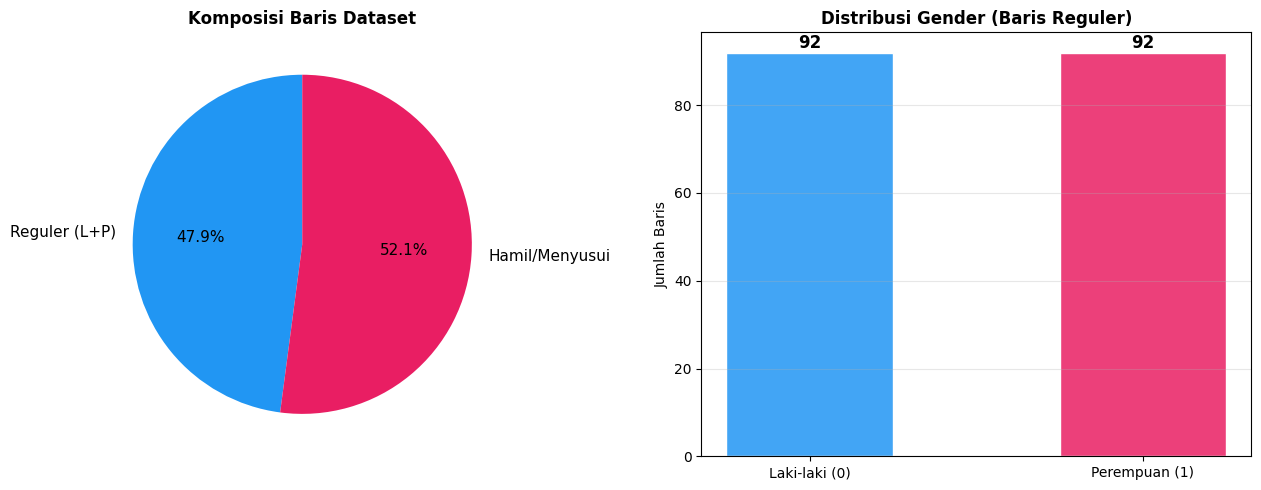

In [7]:
import matplotlib.pyplot as plt

reguler = df[(df['hamil_1_13']==0) & (df['hamil_14_27']==0) & (df['hamil_28_41']==0) &
             (df['menyusui_6bl_pertama']==0) & (df['menyusui_6bl_kedua']==0)]
khusus = df[~df.index.isin(reguler.index)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels_pie = ['Reguler (L+P)', 'Hamil/Menyusui']
sizes_pie = [len(reguler), len(khusus)]
colors_pie = ['#2196F3', '#E91E63']
axes[0].pie(sizes_pie, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Komposisi Baris Dataset', fontsize=12, fontweight='bold')

gender_counts = reguler['gender'].value_counts().sort_index()
axes[1].bar(['Laki-laki (0)', 'Perempuan (1)'], gender_counts.values,
            color=['#42A5F5', '#EC407A'], edgecolor='white', width=0.5)
for j, val in enumerate(gender_counts.values):
    axes[1].text(j, val+1, str(val), ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Baris')
axes[1].set_title('Distribusi Gender (Baris Reguler)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('komposisi_dataset_akg.png', dpi=150, bbox_inches='tight')
plt.show()

Diagram di atas menunjukkan bahwa dari total 384 baris, sebagian besar merupakan baris reguler (laki-laki dan perempuan tanpa kondisi khusus), sedangkan sisanya merupakan baris tambahan untuk kondisi hamil dan menyusui. Pada baris reguler, jumlah data laki-laki dan perempuan relatif seimbang, dengan sedikit perbedaan akibat ketiadaan data gender terpisah pada kelompok bayi dan anak usia 0–9 tahun yang bersifat unisex (dicatat sebagai kedua gender).

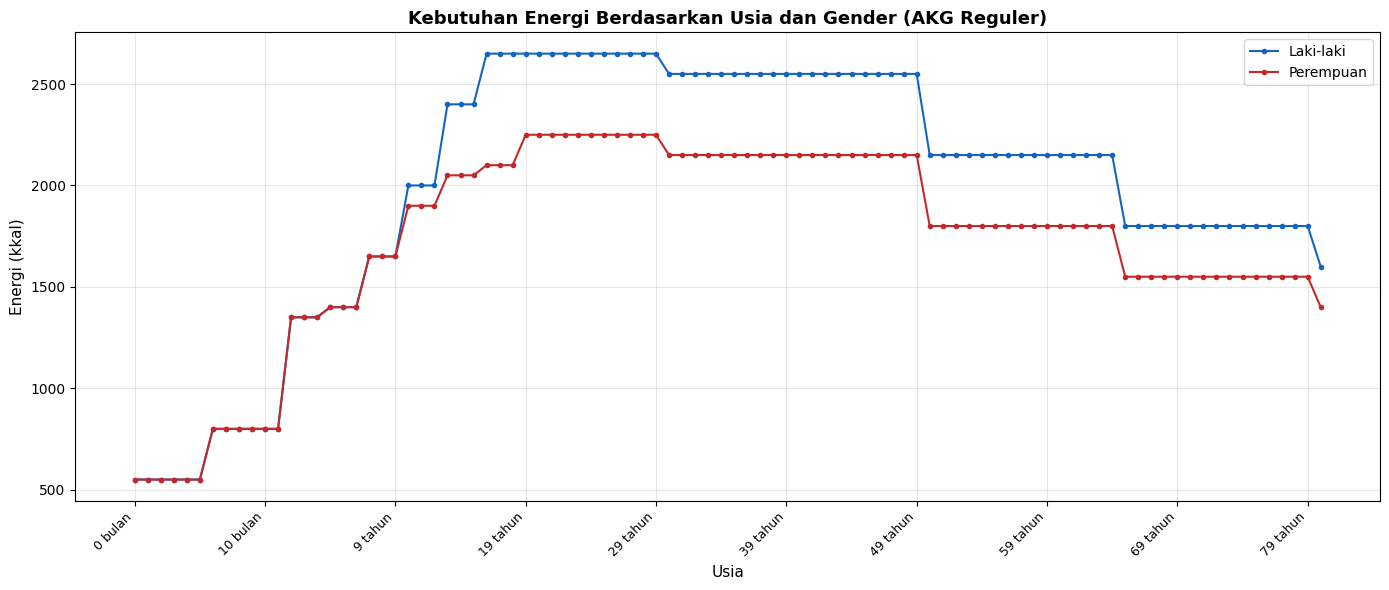

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

for g, label, color in [(0, 'Laki-laki', '#1565C0'), (1, 'Perempuan', '#C62828')]:
    subset = reguler[reguler['gender'] == g].copy()
    subset['usia_num'] = range(len(subset))
    ax.plot(subset['usia_num'], subset['energi_kkal'], marker='o', markersize=3,
            label=label, color=color, linewidth=1.5)

xtick_pos = list(range(0, len(reguler[reguler['gender']==0]), 10))
xtick_labels = reguler[reguler['gender']==0]['usia'].iloc[xtick_pos].tolist()
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Usia', fontsize=11)
ax.set_ylabel('Energi (kkal)', fontsize=11)
ax.set_title('Kebutuhan Energi Berdasarkan Usia dan Gender (AKG Reguler)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('energi_per_usia_gender.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik di atas menampilkan pola kebutuhan energi sepanjang siklus kehidupan untuk kedua gender. Pada usia 0–9 tahun, nilai energi bersifat unisex sehingga kedua kurva berimpit. Mulai usia 10 tahun, kebutuhan energi laki-laki meningkat lebih tajam dan mencapai puncak pada rentang usia 16–29 tahun (2.650 kkal), sedangkan kebutuhan energi perempuan mencapai puncak pada usia 19–29 tahun (2.250 kkal). Setelah usia 50 tahun, kebutuhan energi kedua gender menurun secara bertahap seiring penurunan metabolisme basal, dengan laki-laki tetap memiliki kebutuhan yang lebih tinggi dibandingkan perempuan pada setiap kelompok usia.

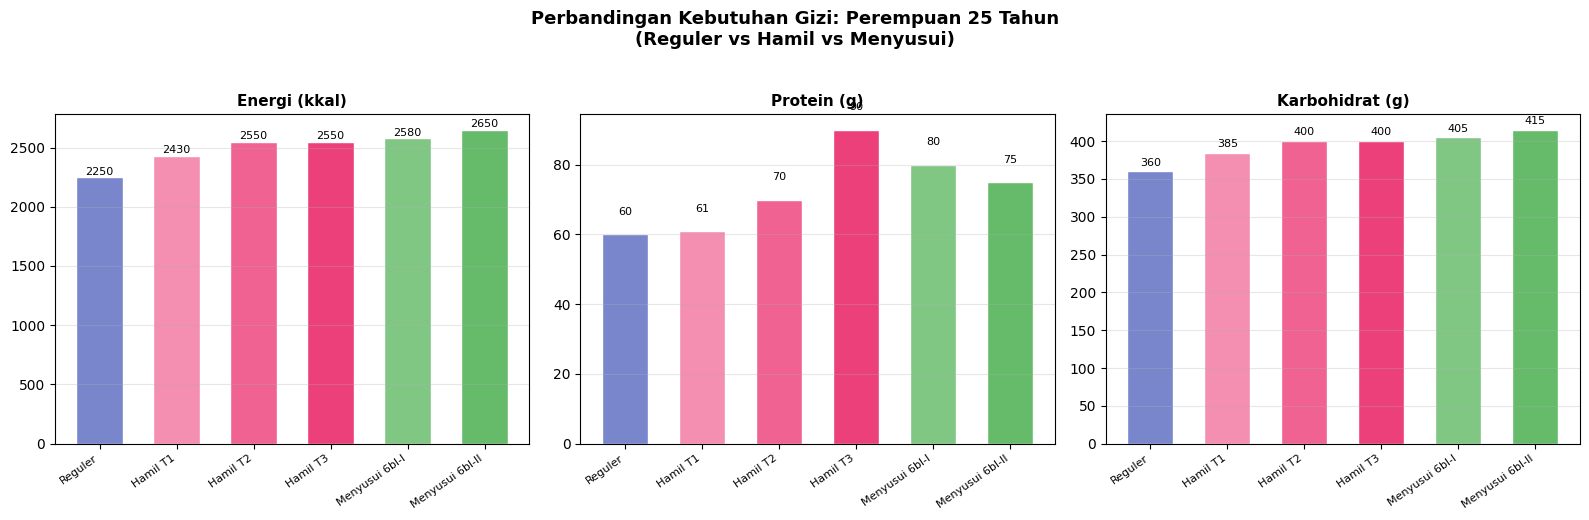

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

nutrients = ['energi_kkal', 'protein_g', 'karbohidrat_g']
titles = ['Energi (kkal)', 'Protein (g)', 'Karbohidrat (g)']
kondisi_labels = ['Reguler', 'Hamil T1', 'Hamil T2', 'Hamil T3', 'Menyusui 6bl-I', 'Menyusui 6bl-II']
kondisi_cols = [None, 'hamil_1_13', 'hamil_14_27', 'hamil_28_41', 'menyusui_6bl_pertama', 'menyusui_6bl_kedua']
bar_colors = ['#7986CB', '#F48FB1', '#F06292', '#EC407A', '#81C784', '#66BB6A']

p25 = df[(df['usia'] == '25 tahun') & (df['gender'] == 1)]

for ax, nut, title in zip(axes, nutrients, titles):
    vals = []
    for kcol in kondisi_cols:
        if kcol is None:
            row = p25[(p25['hamil_1_13']==0) & (p25['hamil_14_27']==0) & (p25['hamil_28_41']==0) &
                       (p25['menyusui_6bl_pertama']==0) & (p25['menyusui_6bl_kedua']==0)]
        else:
            row = p25[p25[kcol] == 1]
        vals.append(row[nut].values[0] if len(row) > 0 else 0)

    bars = ax.bar(range(len(vals)), vals, color=bar_colors, edgecolor='white', width=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f'{v:.0f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(kondisi_labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Kebutuhan Gizi: Perempuan 25 Tahun\n(Reguler vs Hamil vs Menyusui)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('perbandingan_reguler_hamil_menyusui.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik perbandingan pada contoh kasus perempuan usia 25 tahun menunjukkan peningkatan kebutuhan gizi yang signifikan pada kondisi hamil dan menyusui. Kebutuhan energi meningkat dari 2.250 kkal (reguler) menjadi 2.430 kkal pada trimester pertama dan 2.550 kkal pada trimester kedua dan ketiga. Kondisi menyusui 6 bulan kedua menunjukkan peningkatan energi tertinggi (2.650 kkal), yang mencerminkan tingginya kebutuhan energi untuk produksi ASI. Pola yang sama terlihat pada protein dan karbohidrat, di mana trimester ketiga kehamilan dan periode menyusui memerlukan peningkatan protein yang paling besar, sejalan dengan kebutuhan pertumbuhan janin dan produksi ASI.

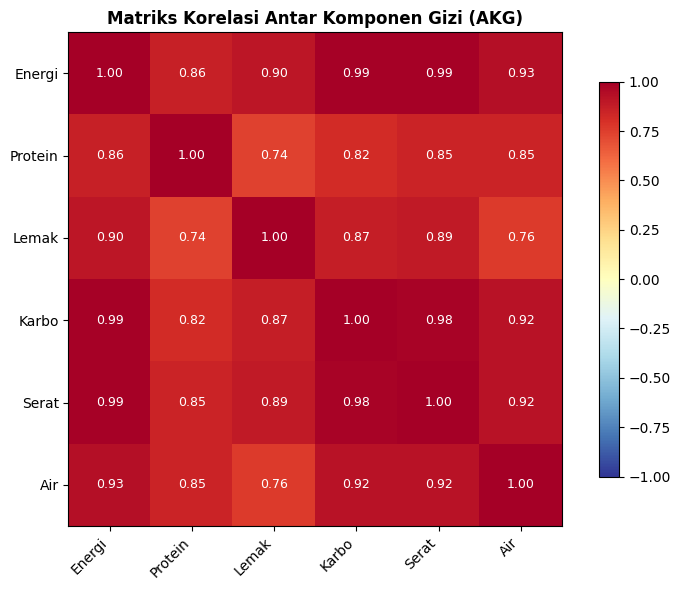

In [10]:
import numpy as np

nutrient_cols = ['energi_kkal', 'protein_g', 'lemak_total_g', 'karbohidrat_g', 'serat_g', 'air_ml']
corr = df[nutrient_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdYlBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(nutrient_cols)))
ax.set_yticks(range(len(nutrient_cols)))
ax.set_xticklabels(['Energi', 'Protein', 'Lemak', 'Karbo', 'Serat', 'Air'], rotation=45, ha='right')
ax.set_yticklabels(['Energi', 'Protein', 'Lemak', 'Karbo', 'Serat', 'Air'])

for i in range(len(nutrient_cols)):
    for j in range(len(nutrient_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(corr.values[i,j]) > 0.6 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriks Korelasi Antar Komponen Gizi (AKG)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('korelasi_gizi_akg.png', dpi=150, bbox_inches='tight')
plt.show()

Matriks korelasi di atas menunjukkan bahwa seluruh komponen gizi dalam tabel AKG memiliki korelasi positif yang kuat satu sama lain. Hal ini sesuai dengan ekspektasi karena kebutuhan gizi meningkat secara proporsional seiring bertambahnya usia dan ukuran tubuh. Korelasi tertinggi terlihat antara energi dan karbohidrat, yang logis mengingat karbohidrat merupakan sumber energi utama dalam pola makan Indonesia. Korelasi antara serat dan karbohidrat juga tinggi karena peningkatan kebutuhan serat sejalan dengan peningkatan asupan karbohidrat kompleks.

In [11]:
import pandas as pd

output_path = 'dataset_AKG_Lengkap.xlsx'
keterangan_data = [
    ('usia', '"0 bulan" s/d "11 bulan", "1 tahun" s/d "79 tahun", "80+ tahun"'),
    ('gender', '0 = Laki-laki, 1 = Perempuan'),
    ('hamil_1_13', '0 = Tidak, 1 = Hamil minggu 1–13'),
    ('hamil_14_27', '0 = Tidak, 1 = Hamil minggu 14–27'),
    ('hamil_28_41', '0 = Tidak, 1 = Hamil minggu 28–41'),
    ('menyusui_6bl_pertama', '0 = Tidak, 1 = Menyusui 6 bulan pertama'),
    ('menyusui_6bl_kedua', '0 = Tidak, 1 = Menyusui 6 bulan kedua'),
    ('Catatan', 'Nilai nutrisi hamil/menyusui = nilai reguler perempuan usia tsb + nilai tambahan AKG.')
]
df_ket = pd.DataFrame(keterangan_data, columns=['Nama Kolom', 'Keterangan/Nilai Dummy'])
with pd.ExcelWriter(output_path) as writer:
    df.drop(columns=['berat_badan_kg', 'tinggi_badan_cm', 'lemak_omega6_g',	'lemak_omega3_g', 'serat_g',	'air_ml'
], errors='ignore').to_excel(writer, sheet_name='Dataset', index=False)

    df_ket.to_excel(writer, sheet_name='Keterangan', index=False)

print(f'Dataset dan Keterangan berhasil disimpan ke: {output_path}')

Dataset dan Keterangan berhasil disimpan ke: dataset_AKG_Lengkap.xlsx


Dataset final telah disimpan ke file `dataset_AKG_Lengkap.xlsx` yang terdiri dari dua sheet, yaitu sheet 'Dataset' yang berisi seluruh 384 baris data AKG (dengan kolom `berat_badan_kg`, `tinggi_badan_cm`, `lemak_omega6_g`, `lemak_omega3_g`, `serat_g`, dan `air_ml` dihapus dari output untuk keperluan penggunaan akhir), serta sheet 'Keterangan' yang memuat penjelasan mengenai setiap kolom dan kode dummy yang digunakan. Dataset ini siap digunakan sebagai referensi kebutuhan gizi pada sistem rekomendasi makanan atau aplikasi pemantauan asupan nutrisi.